# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need.

If you have any questions please contact roman.studer@fhnw.ch

###  Team Name and Members
<span style="color: red;"><strong>Jonathan Muller and Mouni Sattenapally</span>


### Some Guidelines

- You are allowed to use generative models (e.g. ChatGPT, Claude etc.) for code completion or suggestions. However, we require you to perfectly understand and control the code.
- You are **not** allowed to use the same or similar generative models for providing reflection on the achieved results. __You__ must reflect about what you see and build your own opinion about it.
- You are allowed to create additional python scripts to outsource code snippets to improve readability.

### Upload files from locally

In [ ]:
from google.colab import files
uploaded = files.upload()   # select dataloader.py and other repo files


Saving archive.zip to archive.zip


In [ ]:
# create the folder first
!mkdir -p ./data/images
!mkdir -p ./data/splits

# then unzip into it
!unzip archive.zip -d ./data/images



Archive:  archive.zip
replace ./data/images/Images/1000268201_693b08cb0e.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

### Upload files from google drive

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

if not Path("/data/splits").exists():
  !unzip -q "/content/drive/MyDrive/DeepLearningProject3/data.zip" -d ./

!mkdir -p ./data/images
!cp -rf "/kaggle/input/flickr8k/Images"/* "./data/images/"

!cp "/content/drive/MyDrive/DeepLearningProject3/dataloader.py" .
!cp "/content/drive/MyDrive/DeepLearningProject3/tokenizer.py" .

Mounted at /content/drive


## Project Setup


### 1. Create the virtual environment

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

In [ ]:
# imports
import textwrap

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models import ResNet18_Weights

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader
)
from tokenizer import tokenize

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# TODO: Add your own imports here, if needed.

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


### 2. Download the dataset
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/ìmages`-folder. Make sure to download all the images and placing them in the folder `data/images/`.
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

## Dataloader, Tokenizer

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. |
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. |
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. |
| `<unk>`  | 3 | unknown - not available in vocabulary |

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [ ]:
# Transforms
from torchvision import transforms

IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            # START - MODIFY / EXTEND THIS PART
            transforms.Resize((256, 256)),              # resize slightly larger
            transforms.RandomCrop(IMAGENET_SIZE),       # crop to 224×224
            transforms.RandomHorizontalFlip(),          # augmentation
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            #transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            # END - MODIFY / EXTEND THIS PART
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def build_test_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [ ]:

data_dir = "/content/data"


MIN_WORD_FREQ = 5
MAX_LEN = 40
BATCH_SIZE = 32

In [ ]:

tokenizer = build_tokenizer_from_split(split="train", data_dir = data_dir, min_freq=MIN_WORD_FREQ)

train_loader = create_caption_dataloader(
    split="train",
    data_dir = data_dir,
    tokenizer=tokenizer,
    transform = build_train_transforms(),
    batch_size = BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all")
test_loader = create_caption_dataloader(
    split="test",
    data_dir = data_dir,
    tokenizer=tokenizer,
    transform = build_test_transforms(),
    batch_size = BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="random")


print(f"Total images: {len(train_loader.dataset) + len(test_loader.dataset)}")


images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Training Images: {len(train_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))

print(f"Testing Images: {len(test_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")


Total images: 33983
Vocabulary size: 2,649
Training Images: 32,365
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [25, 20, 8, 13, 13, 19, 8, 10, 10, 9, 12, 14, 9, 19, 8, 13, 14, 15, 14, 10, 16, 17, 15, 6, 12, 12, 25, 11, 10, 8, 12, 13]
Testing Images: 1,618
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [9, 15, 12, 21, 12, 15, 10, 11, 13, 11, 10, 14, 12, 22, 12, 10, 12, 9, 13, 8, 18, 10, 8, 11, 9, 15, 10, 12, 13, 17, 15, 16]


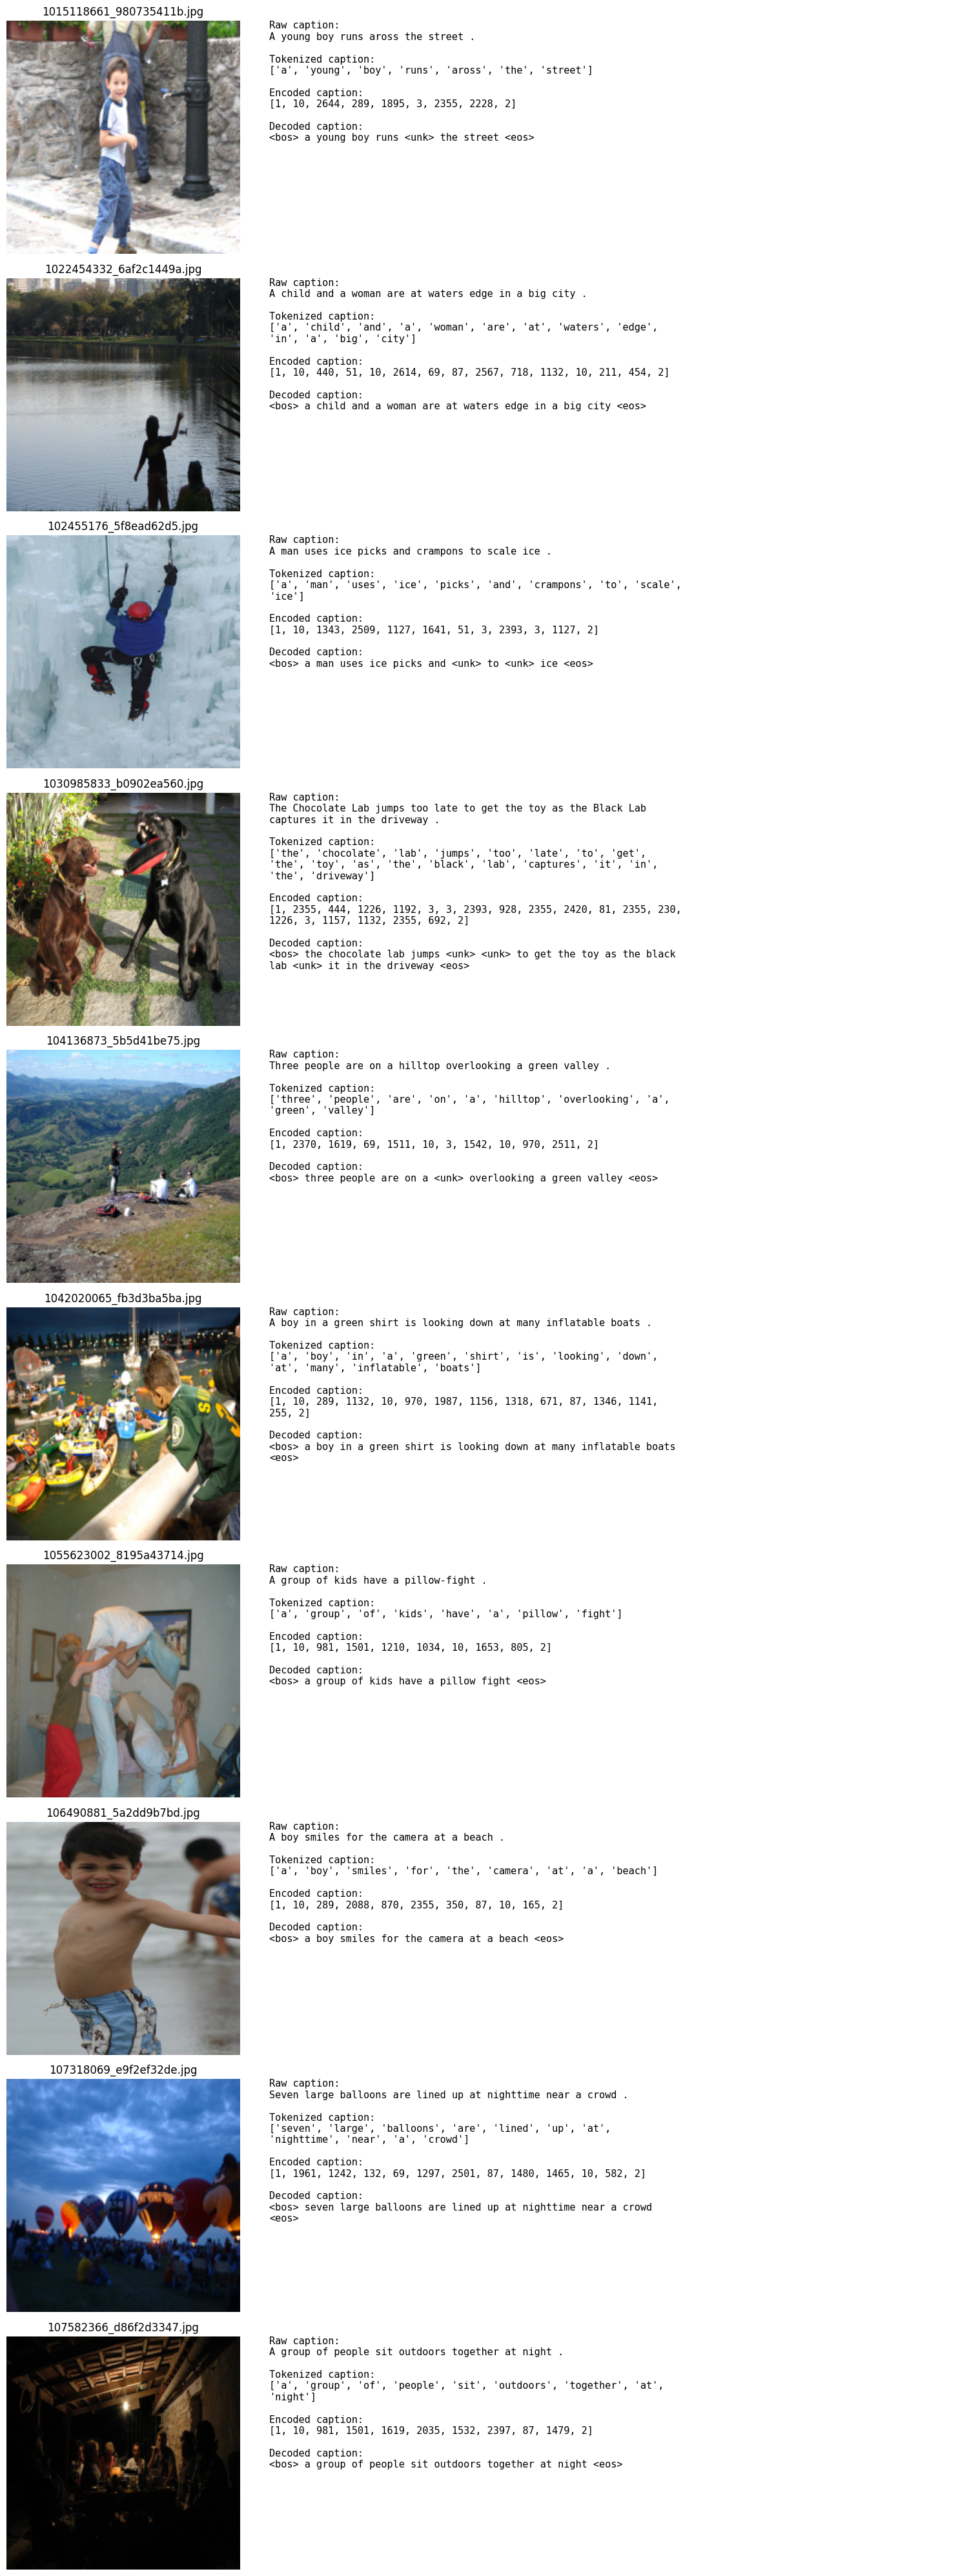

In [ ]:
num_examples = 10
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=70)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=70)}",
            f"Decoded caption:\n{textwrap.fill(decoded_caption, width=70)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualization helpers here. This way your model models stay directly comparable.


In [ ]:
# Define shared config, helper functions, a fixed evaluation subset, and BLEU computation.
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("device:", DEVICE)


# further helper functionality:
# ...

device: cuda


Training and Evaluation

In [ ]:
def word_accuracy(outputs, targets):
    pad_idx = 0
    mask = (targets != pad_idx)
    predicted = outputs.argmax(dim=-1)
    correct = (predicted == targets) & mask
    return correct.sum().item() / mask.sum().item() if mask.sum().item() > 0 else 0.0

def train_one_epoch(model, encoder, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, total_acc = 0, 0
    for images, captions, _, _, _ in dataloader:
        images, captions = images.to(device), captions.to(device)

        optimizer.zero_grad()
        encoder_out = encoder(images)
        outputs = model(encoder_out, captions)   # (B, seq_len or seq_len-1, vocab_size)
        targets = captions[:, 1:].contiguous()   # (B, seq_len-1)

        # Auto‑align: slice outputs if needed
        if outputs.size(1) != targets.size(1):
            outputs = outputs[:, :targets.size(1), :]

        loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
        acc = word_accuracy(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += acc
    return total_loss / len(dataloader), total_acc / len(dataloader)


def evaluate_one_epoch(model, encoder, dataloader, criterion, device, tokenizer):
    model.eval()
    total_loss, total_acc = 0, 0
    hypotheses, references = [], []
    with torch.no_grad():
        for images, captions, _, _, raw_caps in dataloader:
            images, captions = images.to(device), captions.to(device)
            encoder_out = encoder(images)
            outputs = model(encoder_out, captions)
            targets = captions[:, 1:].contiguous()

            if outputs.size(1) != targets.size(1):
                outputs = outputs[:, :targets.size(1), :]

            loss = criterion(outputs.reshape(-1, outputs.size(-1)), targets.reshape(-1))
            acc = word_accuracy(outputs, targets)

            total_loss += loss.item()
            total_acc += acc

            preds = model.generate(
                encoder_out,
                max_len=captions.size(1),
                bos_idx=tokenizer.bos_idx,
                eos_idx=tokenizer.eos_idx,
            )
            for pred in preds:
                hypotheses.append(tokenizer.decode(pred).split())
            references.extend([[ref.split()] for ref in raw_caps])
    return total_loss / len(dataloader), total_acc / len(dataloader), hypotheses, references

from nltk.translate.bleu_score import corpus_bleu
def compute_bleu(references, hypotheses):
    return {
        "BLEU-1": corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0)),
        "BLEU-2": corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0)),
        "BLEU-3": corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0)),
        "BLEU-4": corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25)),
    }

def show_image_with_caption(image_tensor, caption, tokenizer):
    image = denormalize_image(image_tensor.cpu())
    plt.imshow(image.permute(1, 2, 0))
    plt.title(tokenizer.decode(caption))
    plt.axis("off")
    plt.show()


## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper . Record the training behavior, inspect a few generated captions on held-out images, and report BLEU on your fixed evaluation subset.

In [ ]:

ENCODER_DIM = 512      # ResNet18 output
EMBED_DIM = 256        # word embedding size
DECODER_DIM = 512      # LSTM hidden size
DROPOUT = 0.5          # dropout rate
FREEZE_ENCODER = True  # freeze CNN encoder initially


In [ ]:

import torch.nn as nn
import torchvision.models as models

class ShowAndTellEncoder(nn.Module):
    def __init__(self, encoder_dim=ENCODER_DIM, freeze_encoder=FREEZE_ENCODER):
        super().__init__()
        resnet = models.resnet18(pretrained=True)
        modules = list(resnet.children())[:-1]   # remove final FC
        self.cnn = nn.Sequential(*modules)

        if freeze_encoder:
            for p in self.cnn.parameters():
                p.requires_grad = False

        self.encoder_dim = encoder_dim
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.cnn(images)              # (batch, 512, 1, 1)
        features = features.view(features.size(0), -1)  # (batch, 512)
        return features

class ShowAndTellCaptioner(nn.Module):
    def __init__(self, vocab_size, encoder_dim=ENCODER_DIM, embed_dim=EMBED_DIM,
                 decoder_dim=DECODER_DIM, dropout=DROPOUT):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim + encoder_dim, decoder_dim, batch_first=True)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_out: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        captions_input = captions[:, :-1]
        encoder_out = encoder_out.unsqueeze(1)  # (batch, 1, encoder_dim)
        embeddings = self.embed(captions_input)  # (batch, seq_len-1, embed_dim)
        inputs = torch.cat([encoder_out.expand(-1, embeddings.size(1), -1), embeddings], dim=-1)
        outputs, _ = self.lstm(inputs)
        outputs = self.dropout(outputs)
        logits = self.fc(outputs)          # (batch, seq_len-1, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, encoder_out: torch.Tensor, max_len=35, bos_idx=None, eos_idx=None):
        self.eval()
        batch_size = encoder_out.size(0)
        if bos_idx is None:
            bos_idx = tokenizer.bos_idx
        if eos_idx is None:
            eos_idx = tokenizer.eos_idx

        hidden = None
        bos_tokens = torch.tensor([bos_idx] * batch_size, device=encoder_out.device)
        inputs = torch.cat([encoder_out, self.embed(bos_tokens)], dim=-1).unsqueeze(1)
        captions = [[] for _ in range(batch_size)]

        for _ in range(max_len):
            outputs, hidden = self.lstm(inputs, hidden)
            outputs = self.fc(outputs.squeeze(1))  # (batch, vocab_size)
            predicted = outputs.argmax(dim=-1)     # greedy choice

            for i, p in enumerate(predicted.tolist()):
                captions[i].append(p)

            # stop if all EOS
            if all(p == eos_idx for p in predicted.tolist()):
                break

            inputs = torch.cat([encoder_out, self.embed(predicted)], dim=-1).unsqueeze(1)
        return captions

In [ ]:
import torch.optim as optim
import torch.nn as nn

# Initialize encoder + captioner
encoder = ShowAndTellEncoder(encoder_dim=ENCODER_DIM, freeze_encoder=FREEZE_ENCODER).to(DEVICE)
captioner = ShowAndTellCaptioner(
    vocab_size=len(tokenizer),
    encoder_dim=ENCODER_DIM,
    embed_dim=EMBED_DIM,
    decoder_dim=DECODER_DIM,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_idx)
optimizer = optim.Adam(captioner.parameters(), lr=1e-3)
NUM_EPOCHS = 10
train_losses, val_losses, train_accs, val_accs, bleu_scores = [], [], [], [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(captioner, encoder, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, hyps, refs = evaluate_one_epoch(captioner, encoder, test_loader, criterion, DEVICE, tokenizer)
    bleu = compute_bleu(refs, hyps)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    bleu_scores.append(bleu)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("BLEU:", bleu)




/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10
Train Loss: 3.8136 | Val Loss: 3.2383
Train Acc: 0.3064 | Val Acc: 0.3590
BLEU: {'BLEU-1': 0.17972966944729443, 'BLEU-2': 0.08241379885272397, 'BLEU-3': 0.0412526993567697, 'BLEU-4': 0.019396204664125307}
Epoch 2/10
Train Loss: 3.1769 | Val Loss: 3.0428
Train Acc: 0.3574 | Val Acc: 0.3705
BLEU: {'BLEU-1': 0.20237191650853886, 'BLEU-2': 0.1030372500233073, 'BLEU-3': 0.05610370193626844, 'BLEU-4': 0.03034367411571687}
Epoch 3/10
Train Loss: 2.9706 | Val Loss: 2.9221
Train Acc: 0.3742 | Val Acc: 0.3848
BLEU: {'BLEU-1': 0.21162232348473708, 'BLEU-2': 0.10775442792486502, 'BLEU-3': 0.05929218711790088, 'BLEU-4': 0.03197715755443594}
Epoch 4/10
Train Loss: 2.8439 | Val Loss: 2.8743
Train Acc: 0.3857 | Val Acc: 0.3875
BLEU: {'BLEU-1': 0.22463332183152304, 'BLEU-2': 0.11517321429859555, 'BLEU-3': 0.06258010720630021, 'BLEU-4': 0.0323350952504481}
Epoch 5/10
Train Loss: 2.7527 | Val Loss: 2.8440
Train Acc: 0.3949 | Val Acc: 0.3913
BLEU: {'BLEU-1': 0.22703280865343728, 'BLEU-2': 0.119

In [ ]:
images, captions, lengths, _, raw_caps = next(iter(test_loader))
images = images.to(DEVICE)
encoder_out = encoder(images)

# Generate captions
generated = captioner.generate(encoder_out, max_len=MAX_LEN)

# Show a few examples
for i in range(3):
    print("Reference:", raw_caps[i])
    print("Generated:", tokenizer.decode(generated[i]))
    print("---")


Reference: A young boy runs aross the street .
Generated: a man in a red shirt and a blue shirt is standing on a sidewalk
---
Reference: a large lake with a lone duck swimming in it with several people around the edge of it .
Generated: a man in a black shirt is standing in a lake
---
Reference: A person in blue and red ice climbing with two picks .
Generated: a man in a red jacket is skiing down a snowy hill
---


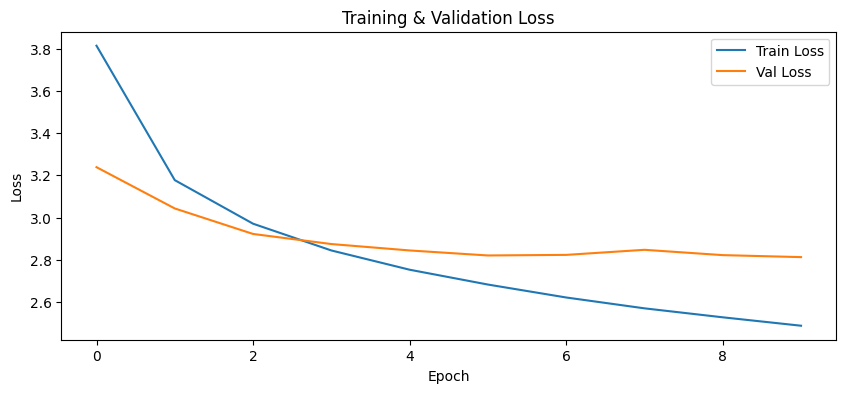

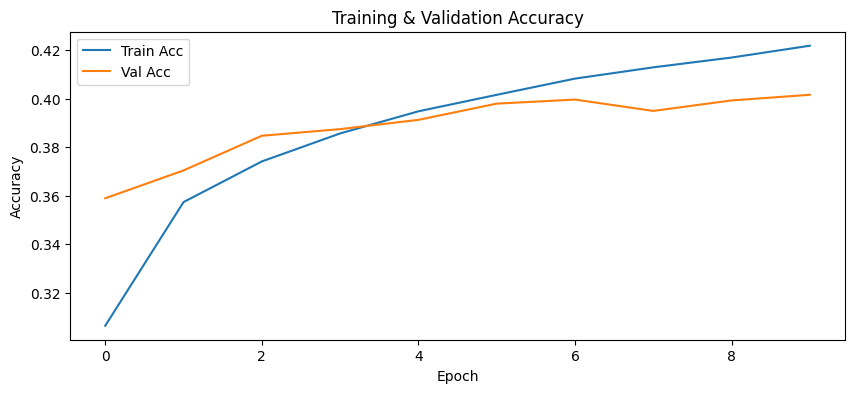

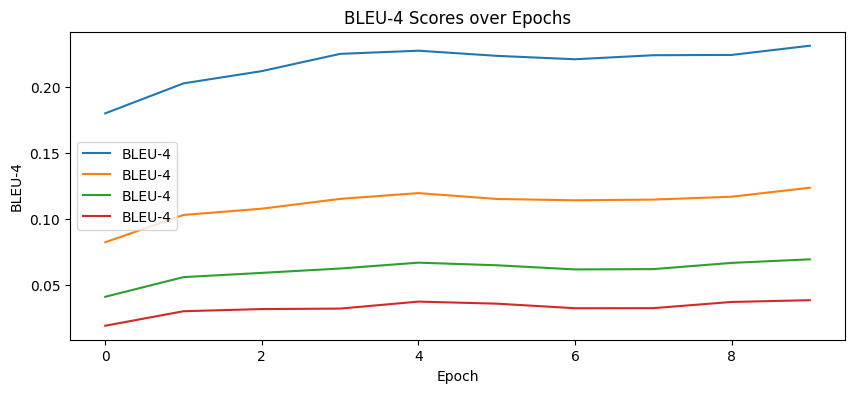

In [ ]:
import matplotlib.pyplot as plt

# Loss curves
plt.figure(figsize=(10,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.show()

# Accuracy curves
plt.figure(figsize=(10,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend(); plt.show()

# BLEU curves (example BLEU-4)
bleu1 = [b["BLEU-1"] for b in bleu_scores]
bleu2 = [b["BLEU-2"] for b in bleu_scores]
bleu3 = [b["BLEU-3"] for b in bleu_scores]
bleu4 = [b["BLEU-4"] for b in bleu_scores]
plt.figure(figsize=(10,4))
plt.plot(bleu1, label="BLEU-4")
plt.plot(bleu2, label="BLEU-4")
plt.plot(bleu3, label="BLEU-4")
plt.plot(bleu4, label="BLEU-4")
plt.xlabel("Epoch"); plt.ylabel("BLEU-4")
plt.title("BLEU-4 Scores over Epochs")
plt.legend(); plt.show()



Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


Model 1 used a ResNet‑18 encoder with the final fully connected layer removed, producing 512‑dimensional features, and an LSTM decoder with 256‑dim word embeddings and 512 hidden units.

Training ran for 10 epochs with dropout 0.5 and Adam at 0.001. Losses dropped steadily (train from 3.8 → 2.48, validation from 3.2 → ~2.81), while accuracy rose to ~42% on training and ~40% on validation, showing the model learned word patterns and sentence structure.
BLEU‑1 to BLEU‑4 scores improved modestly, with BLEU‑1 around 0.23 and BLEU‑4 close to 0.04, reflecting limited overlap with reference captions.
Captions were grammatically correct and fluent but often generic, defaulting to “a man…” instead of capturing specific details like a boy running or a duck swimming.

Overall, the model trained smoothly and produced plausible sentences, but its main limitation was weak grounding in the image content and low semantic accuracy.

## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.


In [ ]:
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet18_Weights

ENCODER_DIM = 512       # ResNet18 feature channels
EMBED_DIM = 256         # word embedding size
DECODER_DIM = 512       # LSTM hidden size
DROPOUT = 0.5           # dropout rate
FREEZE_ENCODER = True   # freeze CNN encoder initially
ATTENTION_DIM = 256     # attention linear layer size


In [ ]:
class ShowAttendTellEncoder(nn.Module):
    def __init__(self, encoder_dim=512, freeze=True):
        super().__init__()
        resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        modules = list(resnet.children())[:-2]  # remove avgpool + fc
        self.cnn = nn.Sequential(*modules)
        if freeze:
            for p in self.cnn.parameters():
                p.requires_grad = False
        self.encoder_dim = encoder_dim

    def forward(self, images: torch.Tensor):
        features = self.cnn(images)              # (B, 512, H/32, W/32)
        B, C, H, W = features.size()
        features = features.view(B, C, -1).permute(0, 2, 1)  # (B, num_pixels, encoder_dim)
        return features

class AdditiveAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att = nn.Linear(encoder_dim, attention_dim)
        self.dec_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)


    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
      att1 = self.enc_att(encoder_out)                  # (B, num_pixels, att_dim)
      att2 = self.dec_att(decoder_hidden).unsqueeze(1) # (B, 1, att_dim)
      att = torch.tanh(att1 + att2)
      scores = self.full_att(att).squeeze(2)           # (B, num_pixels)
      alpha = F.softmax(scores, dim=1)                 # attention weights
      context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, encoder_dim)
      return context, alpha


class ShowAttendTellCaptioner(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, decoder_dim=512,
                 encoder_dim=512, attention_dim=256, dropout=0.5):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.attention = AdditiveAttention(encoder_dim, decoder_dim, attention_dim)
        self.lstm = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)


    def forward(self, encoder_out: torch.Tensor, captions: torch.Tensor):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)

        hidden = torch.zeros(batch_size, self.lstm.hidden_size).to(encoder_out.device)
        cell   = torch.zeros(batch_size, self.lstm.hidden_size).to(encoder_out.device)

        outputs = []
        for t in range(seq_len):
            emb = self.embed(captions[:, t])
            context, _ = self.attention(encoder_out, hidden)
            lstm_input = torch.cat([emb, context], dim=1)
            hidden, cell = self.lstm(lstm_input, (hidden, cell))
            out = self.fc(self.dropout(hidden))
            outputs.append(out.unsqueeze(1))
        return torch.cat(outputs, dim=1)  # (B, seq_len, vocab_size)

    @torch.no_grad()
    def generate(self, encoder_out: torch.Tensor, max_len=35, bos_idx=1, eos_idx=2):
        batch_size = encoder_out.size(0)
        hidden = torch.zeros(batch_size, self.lstm.hidden_size).to(encoder_out.device)
        cell   = torch.zeros(batch_size, self.lstm.hidden_size).to(encoder_out.device)

        inputs = torch.tensor([bos_idx]*batch_size).to(encoder_out.device)
        captions = [[] for _ in range(batch_size)]

        for _ in range(max_len):
            emb = self.embed(inputs)
            context, _ = self.attention(encoder_out, hidden)
            lstm_input = torch.cat([emb, context], dim=1)
            hidden, cell = self.lstm(lstm_input, (hidden, cell))
            out = self.fc(hidden)
            predicted = out.argmax(dim=1)

            for i, p in enumerate(predicted.tolist()):
                captions[i].append(p)

            inputs = predicted
            if all(p == eos_idx for p in predicted.tolist()):
                break
        return captions

In [ ]:
encoder2 = ShowAndTellEncoder(encoder_dim=ENCODER_DIM, freeze_encoder=FREEZE_ENCODER).to(DEVICE)

# Attention-based captioner
captioner2 = ShowAttendTellCaptioner(
    vocab_size=len(tokenizer),
    embed_dim=EMBED_DIM,
    decoder_dim=DECODER_DIM,
    encoder_dim=ENCODER_DIM,
    attention_dim=ATTENTION_DIM,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_idx)
optimizer = optim.Adam(captioner2.parameters(), lr=1e-3)

NUM_EPOCHS = 10
train_losses2, val_losses2, train_accs2, val_accs2, bleu_scores2 = [], [], [], [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(captioner2, encoder2, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, hyps, refs = evaluate_one_epoch(captioner2, encoder2, test_loader, criterion, DEVICE, tokenizer)
    bleu = compute_bleu(refs, hyps)

    train_losses2.append(train_loss)
    val_losses2.append(val_loss)
    train_accs2.append(train_acc)
    val_accs2.append(val_acc)
    bleu_scores2.append(bleu)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("BLEU:", bleu)


Epoch 1/10
Train Loss: 3.9488 | Val Loss: 3.4564
Train Acc: 0.2895 | Val Acc: 0.3289
BLEU: {'BLEU-1': 0.05195724954931755, 'BLEU-2': 0.021028733369709496, 'BLEU-3': 0.009526603177486144, 'BLEU-4': 0.0043375455014430546}
Epoch 2/10
Train Loss: 3.4103 | Val Loss: 3.2317
Train Acc: 0.3324 | Val Acc: 0.3445
BLEU: {'BLEU-1': 0.11379293254695941, 'BLEU-2': 0.049586446629375315, 'BLEU-3': 0.024026161658003923, 'BLEU-4': 0.011549979394734377}
Epoch 3/10
Train Loss: 3.2460 | Val Loss: 3.1690
Train Acc: 0.3447 | Val Acc: 0.3534
BLEU: {'BLEU-1': 0.18493150714090073, 'BLEU-2': 0.08419520585533864, 'BLEU-3': 0.03655709878415351, 'BLEU-4': 0.015015532882840181}
Epoch 4/10
Train Loss: 3.1461 | Val Loss: 3.1112
Train Acc: 0.3520 | Val Acc: 0.3651
BLEU: {'BLEU-1': 0.18814676404608321, 'BLEU-2': 0.08816170228082937, 'BLEU-3': 0.03875743584582633, 'BLEU-4': 0.018025884332338142}
Epoch 5/10
Train Loss: 3.0751 | Val Loss: 3.0665
Train Acc: 0.3587 | Val Acc: 0.3673
BLEU: {'BLEU-1': 0.14463048498845268, 'BLE

In [ ]:
images, captions, lengths, _, raw_caps = next(iter(test_loader))
images = images.to(DEVICE)
encoder_out = encoder(images)

# Generate captions
generated = captioner.generate(encoder_out, max_len=MAX_LEN)

# Show a few examples
for i in range(3):
    print("Reference:", raw_caps[i])
    print("Generated:", tokenizer.decode(generated[i]))
    print("---")


Reference: Smiling boy in white shirt and blue jeans in front of rock wall with man in overalls behind him .
Generated: a man in a red shirt and a blue shirt is standing on a sidewalk
---
Reference: A little boy at a lake watching a duck .
Generated: a man in a black shirt is standing in a lake
---
Reference: A person in blue and red ice climbing with two picks .
Generated: a man in a red jacket is skiing down a snowy hill
---


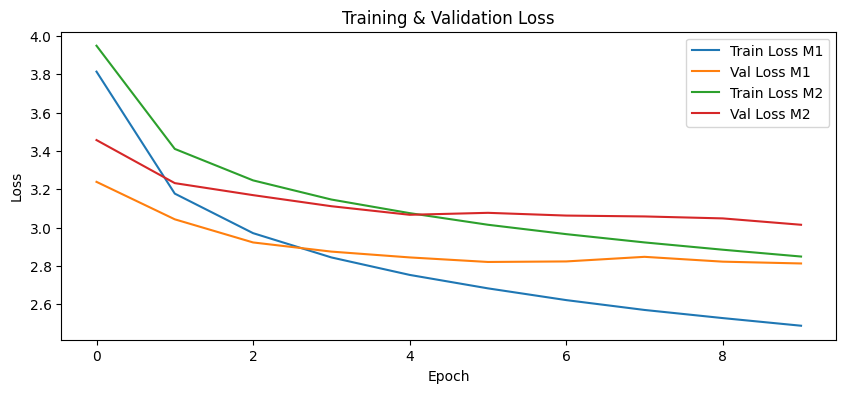

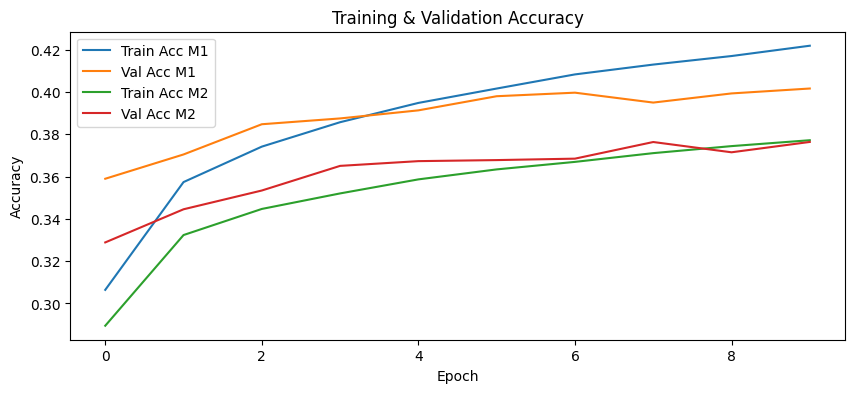

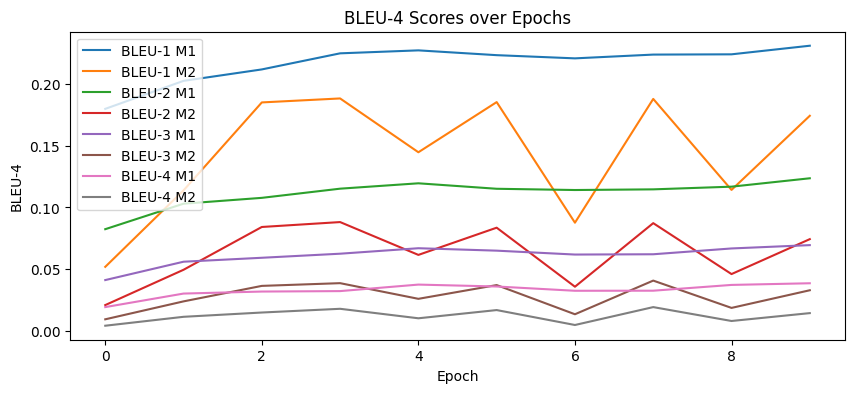

In [ ]:
import matplotlib.pyplot as plt

# Loss curves
plt.figure(figsize=(10,4))
plt.plot(train_losses, label="Train Loss M1")
plt.plot(val_losses, label="Val Loss M1")
plt.plot(train_losses2, label="Train Loss M2")
plt.plot(val_losses2, label="Val Loss M2")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.show()

# Accuracy curves
plt.figure(figsize=(10,4))
plt.plot(train_accs, label="Train Acc M1")
plt.plot(val_accs, label="Val Acc M1")
plt.plot(train_accs2, label="Train Acc M2")
plt.plot(val_accs2, label="Val Acc M2")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend(); plt.show()

# BLEU curves (example BLEU-4)
bleu1_m1 = [b["BLEU-1"] for b in bleu_scores]
bleu1_m2 = [b["BLEU-1"] for b in bleu_scores2]
bleu2_m1 = [b["BLEU-2"] for b in bleu_scores]
bleu2_m2 = [b["BLEU-2"] for b in bleu_scores2]
bleu3_m1 = [b["BLEU-3"] for b in bleu_scores]
bleu3_m2 = [b["BLEU-3"] for b in bleu_scores2]
bleu4_m1 = [b["BLEU-4"] for b in bleu_scores]
bleu4_m2 = [b["BLEU-4"] for b in bleu_scores2]
plt.figure(figsize=(10,4))
plt.plot(bleu1_m1, label="BLEU-1 M1")
plt.plot(bleu1_m2, label="BLEU-1 M2")
plt.plot(bleu2_m1, label="BLEU-2 M1")
plt.plot(bleu2_m2, label="BLEU-2 M2")
plt.plot(bleu3_m1, label="BLEU-3 M1")
plt.plot(bleu3_m2, label="BLEU-3 M2")
plt.plot(bleu4_m1, label="BLEU-4 M1")
plt.plot(bleu4_m2, label="BLEU-4 M2")
plt.xlabel("Epoch"); plt.ylabel("BLEU-4")
plt.title("BLEU-4 Scores over Epochs")
plt.legend(); plt.show()


Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 2.


Model 2 combined a ResNet‑18 encoder with spatial feature maps and an LSTM decoder enhanced by an additive attention mechanism.

Training ran for 10 epochs with dropout 0.5 and Adam at 0.001. Losses decreased steadily, though validation loss stayed a little higher than Model 1, and accuracy reached about 40% on validation.

BLEU‑1 to BLEU‑4 scores showed modest gains compared to the baseline, especially in higher‑order n‑grams, suggesting attention helped capture longer phrases and richer context.

Captions were sometimes more descriptive, as attention guided the decoder toward relevant image regions, but they still defaulted to generic templates in many cases.

Overall, the model produced more detailed captions than Model 1, but semantic accuracy remained limited, showing that attention improved fluency and detail without fully solving grounding issues.

We kept the hyperparameters the same in the two models to have more consistent results.

The advantage of Model 1 was simplicity and stability, while its limitation was weak grounding.

Model 2’s advantage was richer context and detail, but it still struggled with semantic accuracy and sometimes defaulted to generic templates.

Overall, attention gave Model 2 a slight edge by making captions more descriptive and improving BLEU scores, but both models still struggled with grounding. They produced fluent sentences yet often missed the fine details of the scene.
To truly capture fine‑grained visual meaning, stronger mechanisms beyond attention are needed.

## Additional Task 1: Option ...

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it.

## Additional Task 2: Option ....

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it.